In [1]:
## Decision Trees

In [1]:
# Dataset: Cleaned Titanic

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
# Load and prepare cleaned Titanic data

DATA_PATH = "titanic_cleaned.csv"


def load_data():
    data = pd.read_csv(DATA_PATH)
    y = data["survived"]
    X = data.drop(columns=["survived", "alive"])
    X = pd.get_dummies(X, drop_first=False, dtype=int)
    target_names = np.array(["Did not survive", "Survived"])
    return X, y, target_names


X, y, target_names = load_data()
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Dataset shape:", X.shape)
print("Training shape:", X_train.shape)
print("Test shape:", X_test.shape)
X.head()

Dataset shape: (673, 21)
Training shape: (538, 21)
Test shape: (135, 21)


,pclass,age,sibsp,parch,fare,adult_male,alone,sex_female,sex_male,embarked_C,...,embarked_S,class_First,class_Second,class_Third,who_child,who_man,who_woman,embark_town_Cherbourg,embark_town_Queenstown,embark_town_Southampton
0,3,22.0,1,0,7.2500,True,False,0,1,0,...,1,0,0,1,0,1,0,0,0,1
1,1,38.0,1,0,71.2833,False,False,1,0,1,...,0,1,0,0,0,0,1,1,0,0
2,3,26.0,0,0,7.9250,False,True,1,0,0,...,1,0,0,1,0,0,1,0,0,1
3,1,35.0,1,0,53.1000,False,False,1,0,0,...,1,1,0,0,0,0,1,0,0,1
4,3,35.0,0,0,8.0500,True,True,0,1,0,...,1,0,0,1,0,1,0,0,0,1


In [3]:
# Baseline Titanic Decision Tree (no tuning)

baseline = DecisionTreeClassifier(random_state=42)
baseline.fit(X_train, y_train)
baseline_pred = baseline.predict(X_test)
print("Baseline Tree Accuracy:", accuracy_score(y_test, baseline_pred))
print("Baseline Tree Depth:", baseline.get_depth())

Baseline Tree Accuracy: 0.6370370370370371
Baseline Tree Depth: 22


In [4]:
# Impurity Concept Check

def gini(y_subset):
    _, counts = np.unique(y_subset, return_counts=True)
    p = counts / counts.sum()
    return 1 - np.sum(p ** 2)

print("Gini impurity of full training set:", gini(y_train.values))

Gini impurity of full training set: 0.46417959950802223


In [5]:
#  Hyperparameter Tuning (prevent overfitting)

param_grid = {
    "max_depth": [2, 3, 4, 5, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "criterion": ["gini", "entropy"]
}

grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring="accuracy"
)
grid.fit(X_train, y_train)

print("Best Params:", grid.best_params_)
print("Best CV Accuracy:", grid.best_score_)

best_tree = grid.best_estimator_
best_pred = best_tree.predict(X_test)
print("Tuned Tree Test Accuracy:", accuracy_score(y_test, best_pred))
print(classification_report(y_test, best_pred, target_names=target_names))

Best Params: {'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 4, 'min_samples_split': 10}
Best CV Accuracy: 0.7862755278643129
Tuned Tree Test Accuracy: 0.7851851851851852
                 precision    recall  f1-score   support

Did not survive       0.79      0.90      0.84        86
       Survived       0.76      0.59      0.67        49

       accuracy                           0.79       135
      macro avg       0.78      0.74      0.75       135
   weighted avg       0.78      0.79      0.78       135



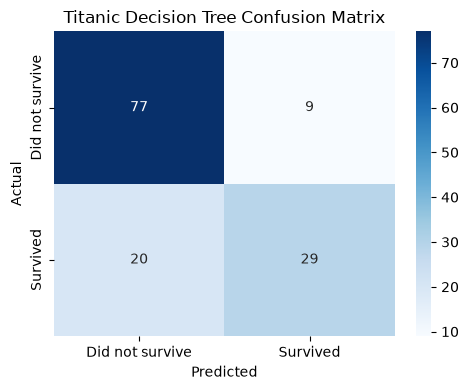

In [6]:
# Confusion Matrix

cm = confusion_matrix(y_test, best_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=target_names, yticklabels=target_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Titanic Decision Tree Confusion Matrix")
plt.tight_layout()
plt.show()

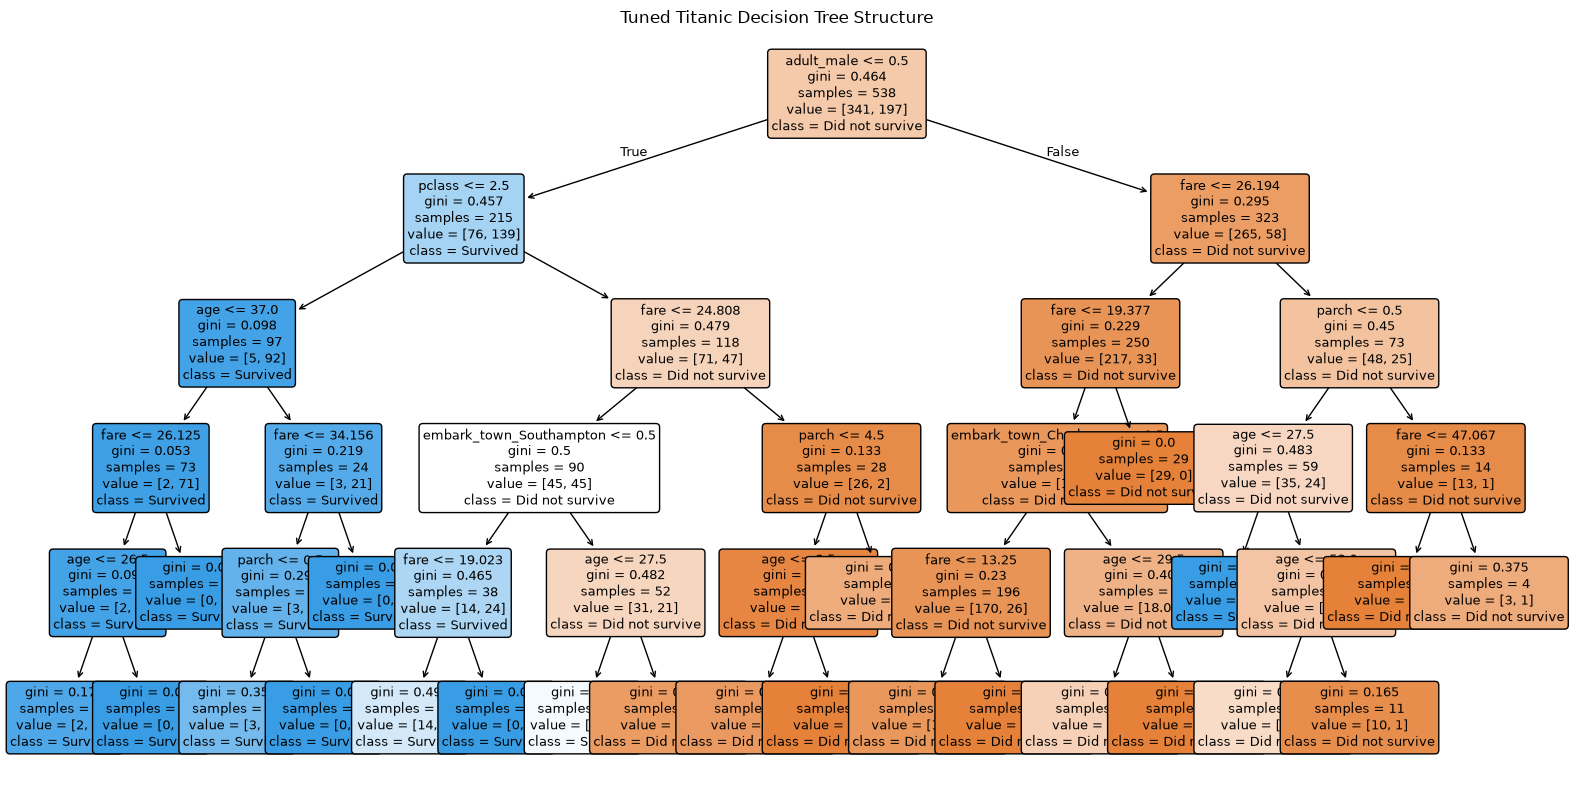

In [7]:
# Tree Visualization

plt.figure(figsize=(16, 8))
plot_tree(best_tree, feature_names=X.columns, class_names=target_names,
          filled=True, rounded=True, fontsize=9)
plt.title("Tuned Titanic Decision Tree Structure")
plt.tight_layout()
plt.show()

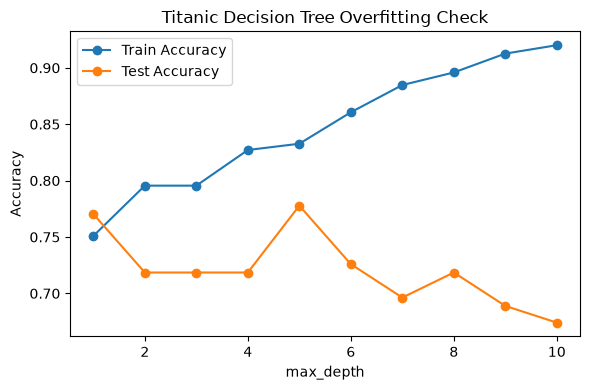

In [9]:
# Overfitting Check: depth vs accuracy

depths = range(1, 11)
train_acc, test_acc = [], []
for d in depths:
    clf = DecisionTreeClassifier(max_depth=d, random_state=42)
    clf.fit(X_train, y_train)
    train_acc.append(clf.score(X_train, y_train))
    test_acc.append(clf.score(X_test, y_test))

plt.figure(figsize=(6, 4))
plt.plot(depths, train_acc, marker="o", label="Train Accuracy")
plt.plot(depths, test_acc, marker="o", label="Test Accuracy")
plt.xlabel("max_depth")
plt.ylabel("Accuracy")
plt.title("Titanic Decision Tree Overfitting Check")
plt.legend()
plt.tight_layout()
plt.show()